In [9]:
import os, sys
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(PROJECT_ROOT)

In [10]:
import pandas as pd
from utils import *
import seaborn as sns

In [17]:
sns.set(style="whitegrid")
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
healthy_orange = '#EC6602'
healthy_orange_50 = '#F9B591'
healthy_orange_25 = '#FDDDCB'
siemens_petrol = '#009999'
siemens_petrol_50 = '#87D2D2'
sns.set_palette([healthy_orange, siemens_petrol, healthy_orange_50, healthy_orange_25, siemens_petrol_50])
RANDOM_SEED = 42

In [12]:
df = pd.read_csv('data/cross_section/CampusFile_WM_2023.csv')
df.head()

/var/folders/46/ky7ff4bj6874xpchl1bc9cqh0000gn/T/ipykernel_15587/4248219091.py:1: DtypeWarning: Columns (1,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/cross_section/CampusFile_WM_2023.csv')


,obid,plz,mietekalt,nebenkosten,heizkosten,baujahr,letzte_modernisierung,wohnflaeche,nutzflaeche,etage,anzahletagen,zimmeranzahl,nebenraeume,schlafzimmer,badezimmer,ev_kennwert,laufzeittage,hits,click_schnellkontakte,click_customer,click_weitersagen,click_url,liste_show,liste_match,immobilientyp,aufzug,balkon,einbaukueche,ev_wwenthalten,foerderung,gaestewc,garten,heizkosten_in_wm_enthalten,keller,parkplatz,rollstuhlgerecht,bauphase,ausstattung,energieeffizienzklasse,energieausweistyp,haustier_erlaubt,heizungsart,kategorie_Wohnung,objektzustand,lieferung,ergg_1km,blid,gid2019,kid2019,bef1,bef2,bef10,bef9,bef8,bef7,bef6,bef5,bef4,bef3,anbieter,hits_gen,click_schnellkontakte_gen,click_weitersagen_gen,click_url_gen,liste_show_gen,liste_match_gen,adat,edat,rent_sqm
0,114949117,24944,575.0,95,80,1972.0,Other missing,50.0,Other missing,3,3,2.0,Old variable (no longer part of the platform),1,1,106,1,118,6,Old variable (no longer part of the platform),0,0,858,890,Flat-rent,Yes,Yes,Yes,Other missing,No,No,No,No,Yes,Yes,No,Variable for other types only,Not specified,D,Energy use [Energieverbauchskennwert],No,District heating,Flat,Well-kept,Dec 2023,4287_3523,Schleswig Holstein,1001000,1001,DISTRICT_HEATING,Other missing,Other missing,Other missing,Other missing,Other missing,Other missing,Other missing,Other missing,Other missing,Real-estate agent,103.00000,1.714286,0.0,0.000000,1570.0000,4997.8569,2023m7,2023m11,11.500000
1,146419628,24944,525.0,230,115,NaN,Other missing,64.0,Other missing,Other missing,Other missing,2.0,Old variable (no longer part of the platform),Other missing,Other missing,222,54,2511,57,Old variable (no longer part of the platform),0,0,64230,205892,Flat-rent,No,No,Yes,Other missing,No,No,No,Yes,Yes,No,No,Variable for other types only,Not specified,C,Energy use [Energieverbauchskennwert],Not specified,District heating,Attic flat,Not specified,Dec 2023,4287_3522,Schleswig Holstein,1001000,1001,DISTRICT_HEATING,Other missing,Other missing,Other missing,Other missing,Other missing,Other missing,Other missing,Other missing,Other missing,Builder,46.50000,1.055556,0.0,0.000000,1189.4445,3812.8147,2023m10,2023m11,8.203125
2,141408359,24941,504.0,87,107,NaN,Other missing,67.0,Other missing,2,Other missing,3.0,Old variable (no longer part of the platform),Other missing,Other missing,Other missing,21,3150,160,Old variable (no longer part of the platform),0,6,45694,180226,Flat-rent,No,Yes,Yes,Other missing,No,No,No,No,No,Yes,Other missing,Variable for other types only,Normal,Not specified,Not specified,Not specified,District heating,Flat,Not specified,Jun 2023,4284_3518,Schleswig Holstein,1001000,1001,Other missing,Other missing,Other missing,Other missing,Other missing,Other missing,Other missing,Other missing,Other missing,Other missing,Real-estate agent,150.00000,7.619048,0.0,0.285714,2175.9048,8582.1904,2023m4,2023m5,7.522388
3,141428207,24937,470.0,95,175,1900.0,Other missing,58.0,Other missing,4,4,2.0,Old variable (no longer part of the platform),Other missing,Other missing,152.1100006103516,4,71,1,Old variable (no longer part of the platform),0,0,3679,11405,Flat-rent,No,No,Yes,Other missing,No,No,No,No,No,Other missing,No,Variable for other types only,Not specified,E,Energy use [Energieverbauchskennwert],Not specified,District heating,Flat,Not specified,Dec 2023,4284_3520,Schleswig Holstein,1001000,1001,NO_INFORMATION,Other missing,Other missing,Other missing,Other missing,Other missing,Other missing,Other missing,Other missing,Other missing,Real-estate agent,91.86747,1.385542,0.0,0.072289,2770.6748,9922.5781,2023m7,2023m7,8.103448
4,137841818,24939,450.0,80,80,1908.0,Other missing,40.0,5,0,4,2.0,Old variable (no longer part of the platform),1,1,114,1,4312,72,Old variable (no longer part of the platform),0,12,144240,638704,Flat-rent,No,No,No,Other missing,No,No,No,No,No,Other missing,Other missing,Variable for other types only,Not specified,Not specified,Energy use [Energieverbauchskennwert],Not specified,Central heatin

In [21]:
df.replace(to_replace='Other missing', value=np.nan)

,obid,plz,mietekalt,nebenkosten,heizkosten,baujahr,letzte_modernisierung,wohnflaeche,nutzflaeche,etage,anzahletagen,zimmeranzahl,nebenraeume,schlafzimmer,badezimmer,ev_kennwert,laufzeittage,hits,click_schnellkontakte,click_customer,click_weitersagen,click_url,liste_show,liste_match,immobilientyp,aufzug,balkon,einbaukueche,ev_wwenthalten,foerderung,gaestewc,garten,heizkosten_in_wm_enthalten,keller,parkplatz,rollstuhlgerecht,bauphase,ausstattung,energieeffizienzklasse,energieausweistyp,haustier_erlaubt,heizungsart,kategorie_Wohnung,objektzustand,lieferung,ergg_1km,blid,gid2019,kid2019,bef1,bef2,bef10,bef9,bef8,bef7,bef6,bef5,bef4,bef3,anbieter,hits_gen,click_schnellkontakte_gen,click_weitersagen_gen,click_url_gen,liste_show_gen,liste_match_gen,adat,edat,rent_sqm
0,114949117,24944,575.00,95,80,1972.0,NaN,50.00,NaN,3,3,2.0,Old variable (no longer part of the platform),1,1,106,1,118,6,Old variable (no longer part of the platform),0,0,858,890,Flat-rent,Yes,Yes,Yes,NaN,No,No,No,No,Yes,Yes,No,Variable for other types only,Not specified,D,Energy use [Energieverbauchskennwert],No,District heating,Flat,Well-kept,Dec 2023,4287_3523,Schleswig Holstein,1001000,1001,DISTRICT_HEATING,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Real-estate agent,103.000000,1.714286,0.0,0.000000,1570.00000,4997.8569,2023m7,2023m11,11.500000
1,146419628,24944,525.00,230,115,NaN,NaN,64.00,NaN,NaN,NaN,2.0,Old variable (no longer part of the platform),NaN,NaN,222,54,2511,57,Old variable (no longer part of the platform),0,0,64230,205892,Flat-rent,No,No,Yes,NaN,No,No,No,Yes,Yes,No,No,Variable for other types only,Not specified,C,Energy use [Energieverbauchskennwert],Not specified,District heating,Attic flat,Not specified,Dec 2023,4287_3522,Schleswig Holstein,1001000,1001,DISTRICT_HEATING,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Builder,46.500000,1.055556,0.0,0.000000,1189.44450,3812.8147,2023m10,2023m11,8.203125
2,141408359,24941,504.00,87,107,NaN,NaN,67.00,NaN,2,NaN,3.0,Old variable (no longer part of the platform),NaN,NaN,NaN,21,3150,160,Old variable (no longer part of the platform),0,6,45694,180226,Flat-rent,No,Yes,Yes,NaN,No,No,No,No,No,Yes,NaN,Variable for other types only,Normal,Not specified,Not specified,Not specified,District heating,Flat,Not specified,Jun 2023,4284_3518,Schleswig Holstein,1001000,1001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Real-estate agent,150.000000,7.619048,0.0,0.285714,2175.90480,8582.1904,2023m4,2023m5,7.522388
3,141428207,24937,470.00,95,175,1900.0,NaN,58.00,NaN,4,4,2.0,Old variable (no longer part of the platform),NaN,NaN,152.1100006103516,4,71,1,Old variable (no longer part of the platform),0,0,3679,11405,Flat-rent,No,No,Yes,NaN,No,No,No,No,No,NaN,No,Variable for other types only,Not specified,E,Energy use [Energieverbauchskennwert],Not specified,District heating,Flat,Not specified,Dec 2023,4284_3520,Schleswig Holstein,1001000,1001,NO_INFORMATION,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Real-estate agent,91.867470,1.385542,0.0,0.072289,2770.67480,9922.5781,2023m7,2023m7,8.103448
4,137841818,24939,450.00,80,80,1908.0,NaN,40.00,5,0,4,2.0,Old variable (no longer part of the platform),1,1,114,1,4312,72,Old variable (no longer part of the platform),0,12,144240,638704,Flat-rent,No,No,No,NaN,No,No,No,No,No,NaN,NaN,Variable for other types only,Not specified,Not specified,Energy use [Energieverbauchskennwert],Not specified,Central heating,Flat,Completely renovated,Jun 2023,4283_3522,Schleswig Holstein,1001000,1001,DISTRICT_HEATING,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Real-estate agent,125.594940,2.075949,0.0,0.316456,4164.22800,18610.1270,2023m2,2023m2,11.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372837,146179353,4617,306.15,183.69,NaN,NaN,NaN,61.23,NaN,3,4,3.0,Old variable (no longer part of the platform),2,1,NaN,5,3

In [23]:
show_missing_values(df.replace(to_replace='Other missing', value=np.nan))

,Column Name,Min,Max,n Unique,NaN count,NaN percentage,dtype
S. No.,,,,,,,
1,obid,23626380,148076523,369112,0,0.0%,int64
2,plz,nan,nan,4479,11,0.003%,object
3,mietekalt,203.41,2690.0,24745,0,0.0%,float64
4,nebenkosten,nan,nan,9364,10600,2.843%,object
5,heizkosten,nan,nan,5316,271625,72.853%,object
6,baujahr,1500.0,2023.0,416,108211,29.023%,float64
7,letzte_modernisierung,nan,nan,98,257479,69.058%,object
8,wohnflaeche,18.28,154.86,11113,0,0.0%,float64
9,nutzflaeche,nan,nan,6728,283599,76.064%,object


In [28]:
df.columns

Index(['obid', 'plz', 'mietekalt', 'nebenkosten', 'heizkosten', 'baujahr',
       'letzte_modernisierung', 'wohnflaeche', 'nutzflaeche', 'etage',
       'anzahletagen', 'zimmeranzahl', 'nebenraeume', 'schlafzimmer',
       'badezimmer', 'ev_kennwert', 'laufzeittage', 'hits',
       'click_schnellkontakte', 'click_customer', 'click_weitersagen',
       'click_url', 'liste_show', 'liste_match', 'immobilientyp', 'aufzug',
       'balkon', 'einbaukueche', 'ev_wwenthalten', 'foerderung', 'gaestewc',
       'garten', 'heizkosten_in_wm_enthalten', 'keller', 'parkplatz',
       'rollstuhlgerecht', 'bauphase', 'ausstattung', 'energieeffizienzklasse',
       'energieausweistyp', 'haustier_erlaubt', 'heizungsart',
       'kategorie_Wohnung', 'objektzustand', 'lieferung', 'ergg_1km', 'blid',
       'gid2019', 'kid2019', 'bef1', 'bef2', 'bef10', 'bef9', 'bef8', 'bef7',
       'bef6', 'bef5', 'bef4', 'bef3', 'anbieter', 'hits_gen',
       'click_schnellkontakte_gen', 'click_weitersagen_gen', 'click_

In [29]:
df = df.drop(columns=['bef2', 'bef10', 'bef9', 'bef8', 'bef7', 'bef6', 'bef5', 'bef4', 'bef3'])

In [30]:
df.replace(to_replace='Other missing', value=np.nan).dropna().shape

(18, 60)

<Axes: >

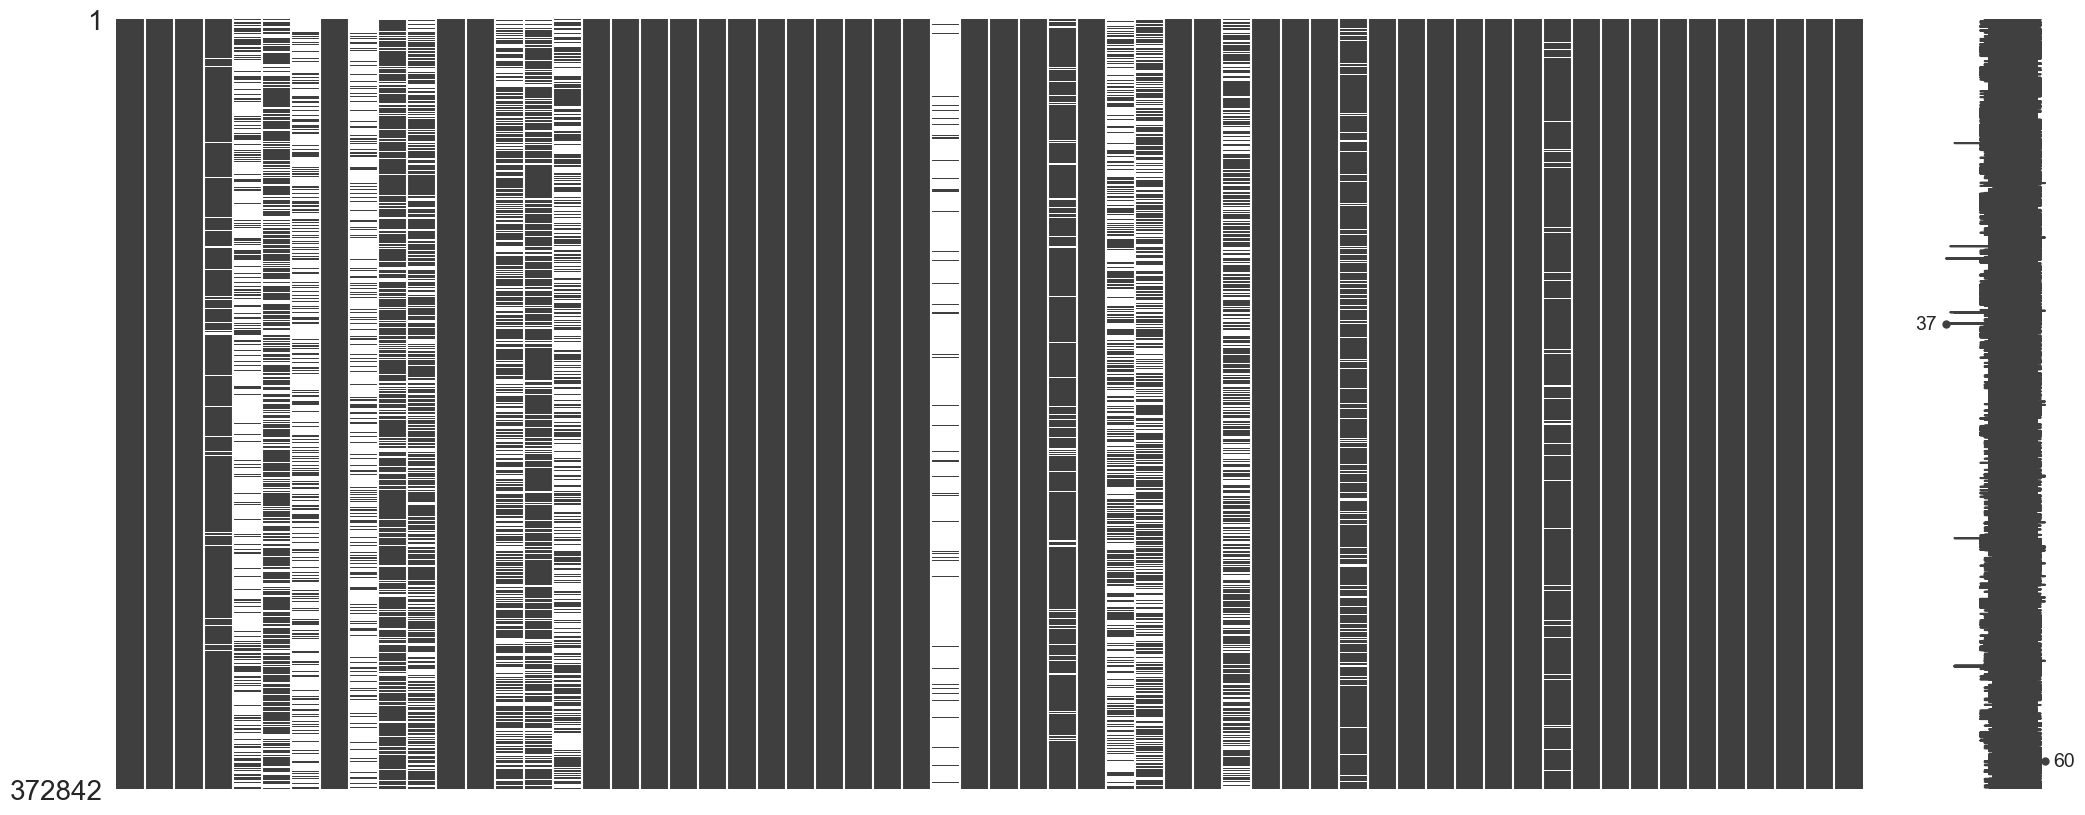

In [31]:
import missingno as msno
msno.matrix(df.replace(to_replace='Other missing', value=np.nan))

<Axes: >

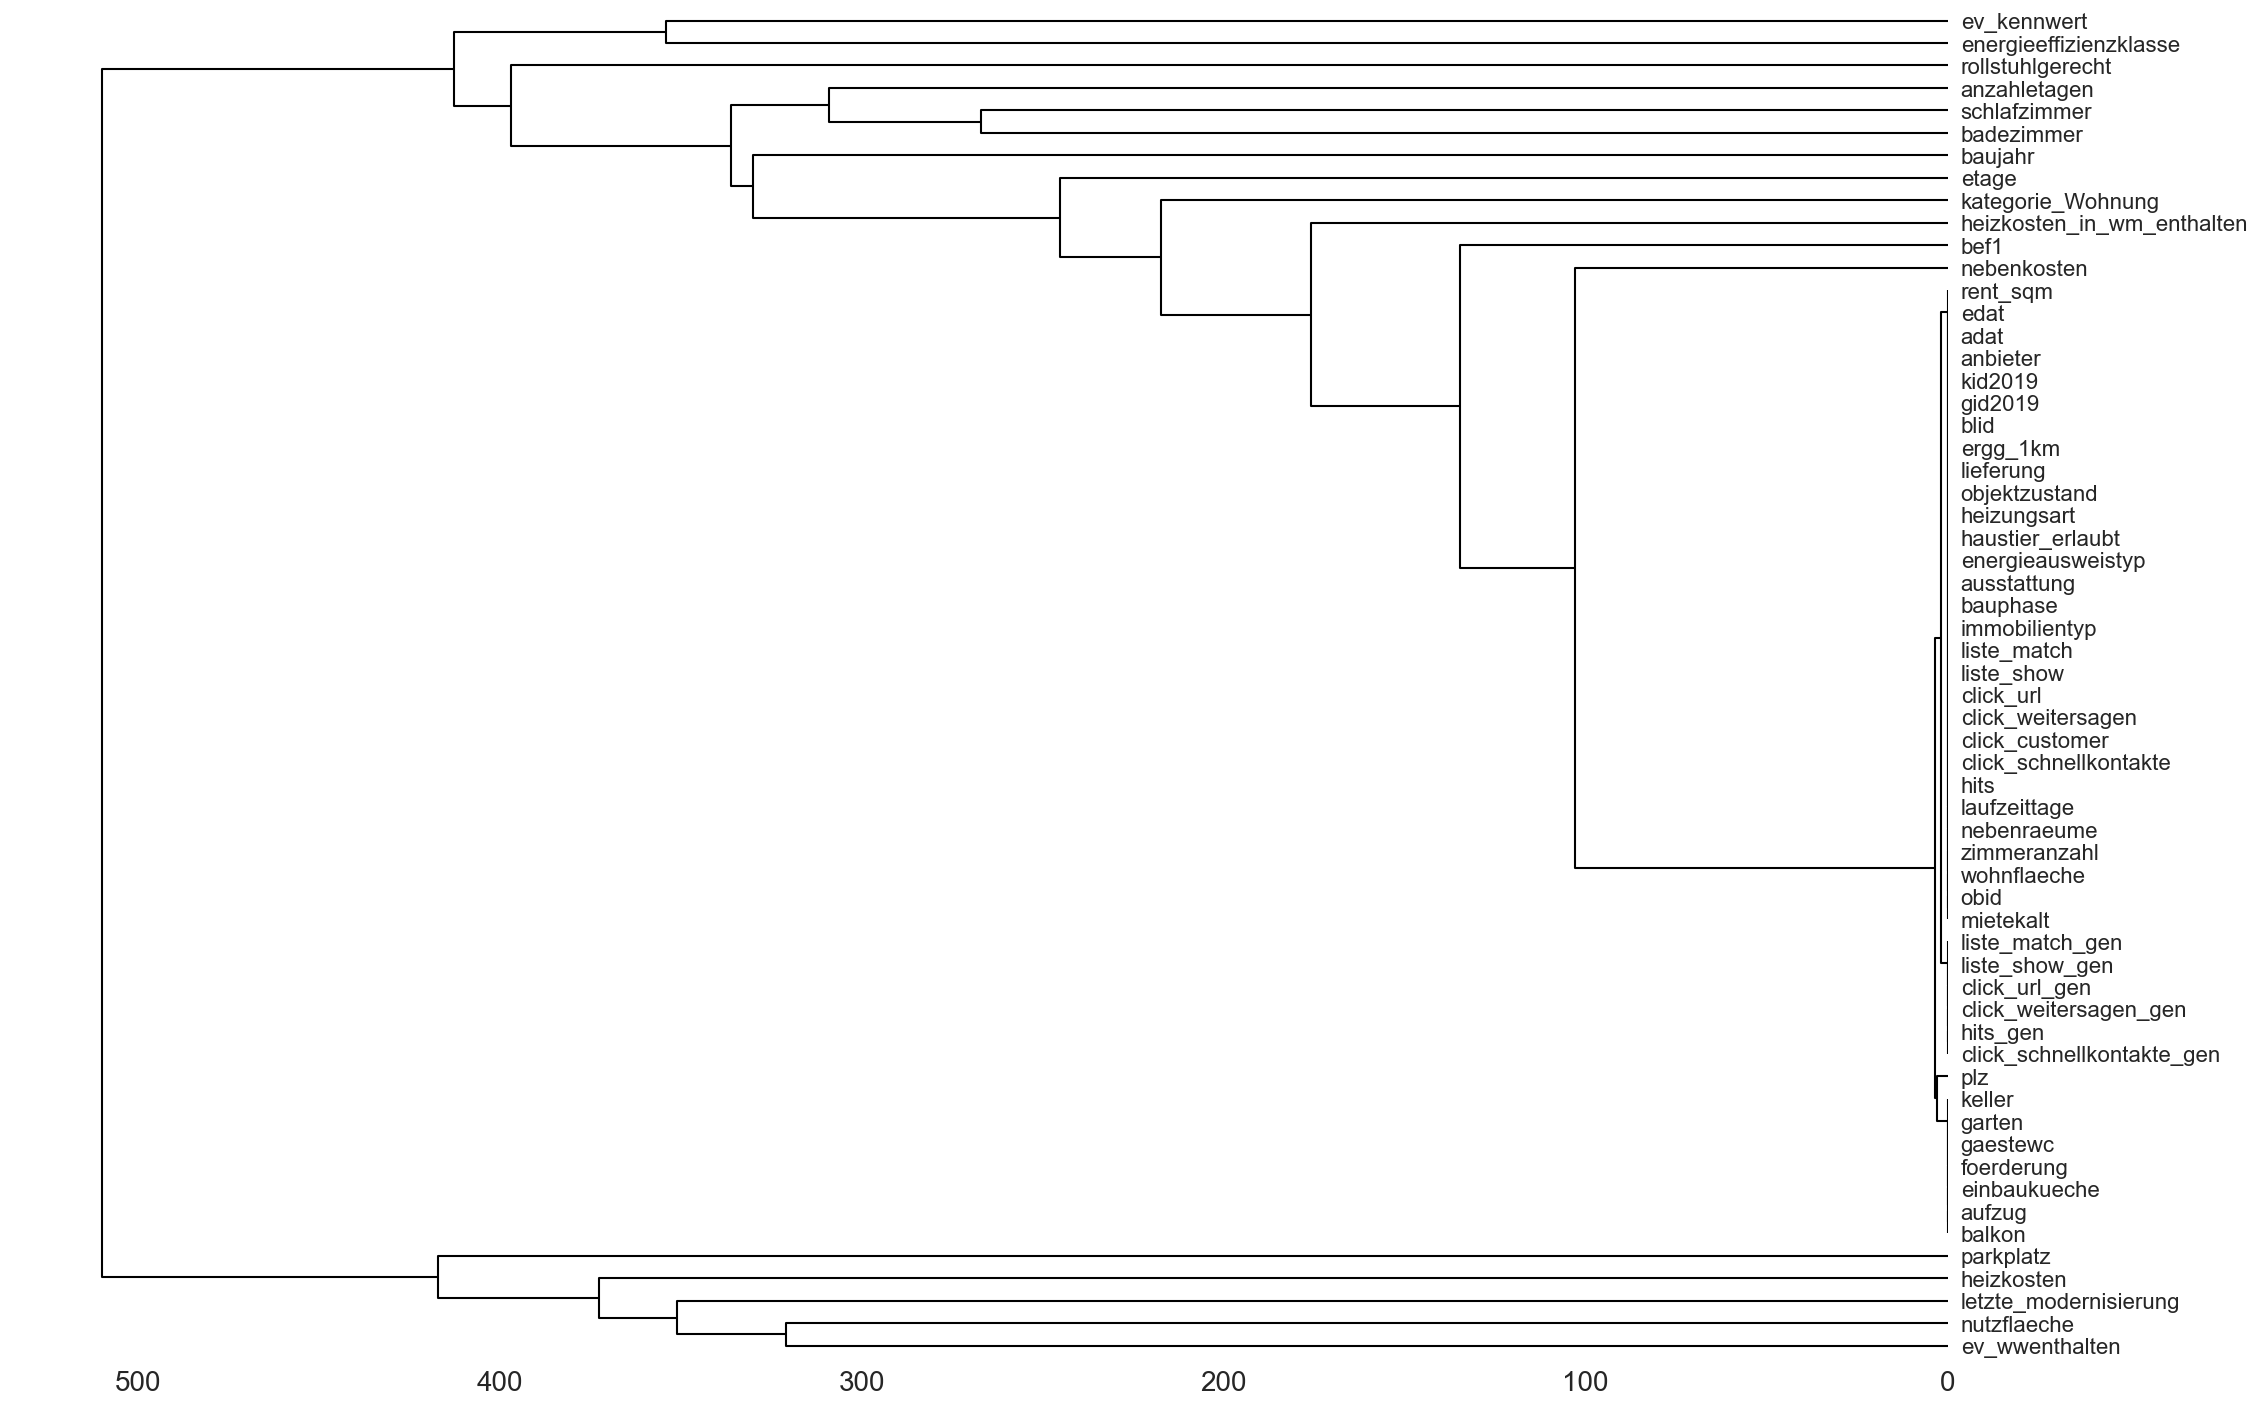

In [32]:
msno.dendrogram(df.replace(to_replace='Other missing', value=np.nan))

In [15]:
df.shape

(372842, 69)

In [19]:
df.baujahr.value_counts().to_csv('baujahr.csv')

In [24]:
matrix = cramers_v_matrix(df.dropna().drop(columns='obid'))
matrix

KeyboardInterrupt: 

In [ ]:
num_corr_heatmap(df.dropna().drop(columns='obid'))